In [95]:
import pandas as pd
from matplotlib import pyplot as plt

import re
import string
import emoji

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score, roc_curve, auc

In [57]:
train = pd.read_csv("./dataset/train (2).csv")
test = pd.read_csv("./dataset/test (1).csv")
val = pd.read_csv("./dataset/dev.csv")

In [58]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /home/yogesh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/yogesh/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/yogesh/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [59]:
train = pd.concat([train, val], axis=0, ignore_index=True)

In [85]:
train.shape[0]

16000

In [61]:
train.duplicated().any()

np.False_

In [62]:
train.head()

,rewire_id,text,label_sexist,label_category,label_vector,split
0,sexism2022_english-16993,"Then, she's a keeper. 😉",not sexist,none,none,train
1,sexism2022_english-13149,This is like the Metallica video where the poo...,not sexist,none,none,train
2,sexism2022_english-13021,woman?,not sexist,none,none,train
3,sexism2022_english-14998,Unlicensed day care worker reportedly tells co...,not sexist,none,none,train
4,sexism2022_english-7228,[USER] Leg day is easy. Hot girls who wear min...,sexist,3. animosity,3.3 backhanded gendered compliments,train


In [63]:
train.drop(columns=['rewire_id', 'label_category', 'label_vector', 'split'], inplace=True)
test.drop(columns=['rewire_id', 'label_category', 'label_vector', 'split'], inplace=True)

In [64]:
def change_column_names(df, text_col, label_col):
    return df.rename(columns={ text_col: "text", label_col: "target"})

In [65]:
train = change_column_names(train, "text", "label_sexist")
test = change_column_names(test, "text", "label_sexist")

In [66]:
train.head()

,text,target
0,"Then, she's a keeper. 😉",not sexist
1,This is like the Metallica video where the poo...,not sexist
2,woman?,not sexist
3,Unlicensed day care worker reportedly tells co...,not sexist
4,[USER] Leg day is easy. Hot girls who wear min...,sexist


In [67]:
stop_words = set(stopwords.words("english"))
negations = {"no", "not", "nor", "never"}
stop_words = stop_words - negations

In [68]:
stemmer = PorterStemmer()

In [69]:
def clean_text(text: str) -> str:
    text = text.lower()

    text = emoji.demojize(text, delimiters=(" ", " "))

    text = re.sub(r"http\S+|www\S+", " URL ", text)
    text = re.sub(r"@\w+", " USER ", text)
    text = re.sub(r"\d+", " NUM ", text)

    text = re.sub(r"!{2,}", " EXCLAMATION ", text)
    text = re.sub(r"\?{2,}", " QUESTION ", text)

    punctuation = string.punctuation.replace("_", "")
    text = text.translate(str.maketrans("", "", punctuation))

    tokens = text.split()

    tokens = [
        stemmer.stem(token)
        for token in tokens
        if token not in stop_words
    ]

    return " ".join(tokens)


In [70]:
print(train['target'].value_counts())
print(test['target'].value_counts())

target
not sexist    12116
sexist         3884
Name: count, dtype: int64
target
not sexist    3030
sexist         970
Name: count, dtype: int64


In [71]:
train["clean_text"] = train["text"].apply(clean_text)
test["clean_text"] = test["text"].apply(clean_text)

In [72]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)

In [73]:
train.columns

Index(['text', 'target', 'clean_text'], dtype='object')

In [74]:
label_map = {
    "not sexist": 0,
    "sexist": 1
}

In [75]:
train["target"] = train["target"].str.strip().str.lower().map(label_map)
test["target"] = test["target"].str.strip().str.lower().map(label_map)

In [76]:
x_train = train['clean_text'].values
x_test = test['clean_text'].values

y_train = train['target'].values
y_test = test['target'].values

In [77]:
x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

In [96]:
logReg = LogisticRegression(max_iter=1000, class_weight="balanced")
svc = SVC(kernel="linear", probability=True)
rfc = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight="balanced", n_jobs=-1, random_state=42)

In [97]:
logReg.fit(x_train_vec, y_train)
svc.fit(x_train_vec, y_train)
rfc.fit(x_train_vec, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [98]:
logReg_pred = logReg.predict(x_test_vec)
svc_pred = svc.predict(x_test_vec)
rfc_pred = rfc.predict(x_test_vec)

In [99]:
print(classification_report(y_true=y_test, y_pred=logReg_pred))
print(classification_report(y_true=y_test, y_pred=svc_pred))
print(classification_report(y_true=y_test, y_pred=rfc_pred))

              precision    recall  f1-score   support

           0       0.90      0.84      0.87      3030
           1       0.59      0.71      0.64       970

    accuracy                           0.81      4000
   macro avg       0.74      0.77      0.76      4000
weighted avg       0.82      0.81      0.81      4000

              precision    recall  f1-score   support

           0       0.85      0.97      0.91      3030
           1       0.84      0.46      0.60       970

    accuracy                           0.85      4000
   macro avg       0.85      0.72      0.75      4000
weighted avg       0.85      0.85      0.83      4000

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      3030
           1       0.68      0.60      0.64       970

    accuracy                           0.84      4000
   macro avg       0.78      0.76      0.77      4000
weighted avg       0.83      0.84      0.83      4000



In [100]:
metrics = ["F1", "Recall", "Precision", "Accuracy"]
f1_scores = [round(f1_score(y_true=y_test, y_pred=logReg_pred), 2), round(f1_score(y_true=y_test, y_pred=svc_pred), 2), round(f1_score(y_true=y_test, y_pred=rfc_pred), 2)]
recall_scores = [round(recall_score(y_true=y_test, y_pred=logReg_pred), 2), round(recall_score(y_true=y_test, y_pred=svc_pred), 2), round(recall_score(y_true=y_test, y_pred=rfc_pred), 2)]
precision_scores = [round(precision_score(y_true=y_test, y_pred=logReg_pred), 2), round(precision_score(y_true=y_test, y_pred=svc_pred), 2), round(precision_score(y_true=y_test, y_pred=rfc_pred), 2)]
accuracy_scores = [round(accuracy_score(y_true=y_test, y_pred=logReg_pred), 2), round(accuracy_score(y_true=y_test, y_pred=svc_pred), 2), round(accuracy_score(y_true=y_test, y_pred=rfc_pred), 2)]

scores = {
    "Logistic Regression": [f1_scores[0], recall_scores[0], precision_scores[0], accuracy_scores[0]],
    "SVC": [f1_scores[1], recall_scores[1], precision_scores[1], accuracy_scores[1]],
    "RandomForest": [f1_scores[2], recall_scores[2], precision_scores[2], accuracy_scores[2]]
}

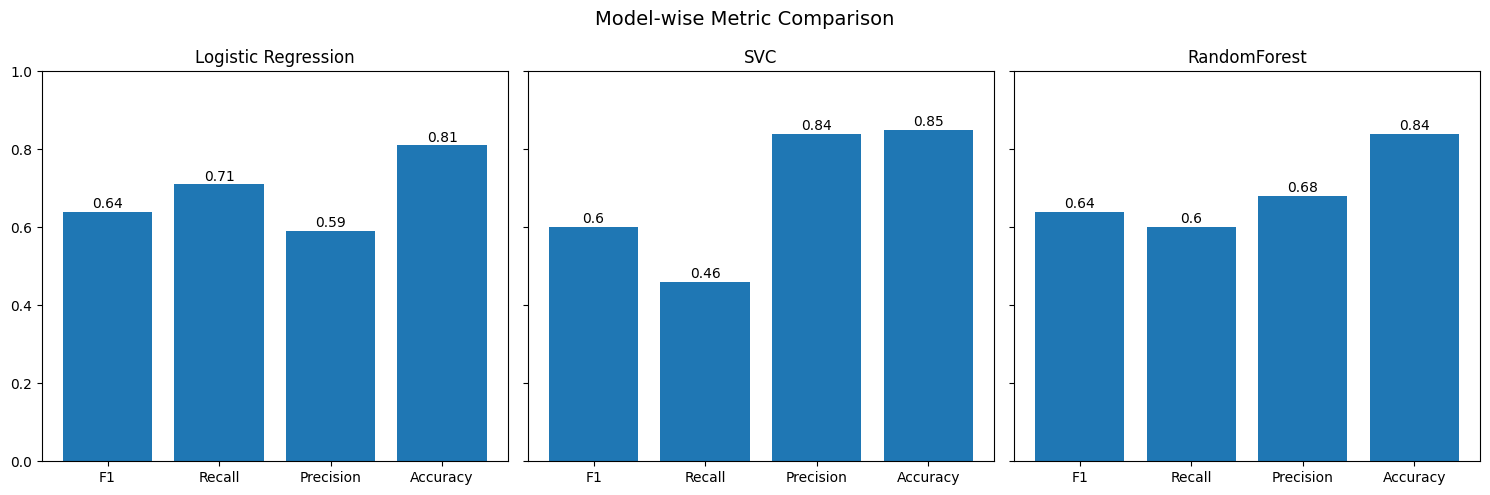

In [101]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (model, vals) in zip(axs, scores.items()):
    ax.bar(metrics, vals)
    ax.set_title(model)
    ax.set_ylim(0, 1)

    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, round(v, 2), ha="center")
        
fig.suptitle("Model-wise Metric Comparison", fontsize=14)
plt.tight_layout()
plt.show()


In [102]:
logreg_scores = logReg.predict_proba(x_test_vec)[:, 1]
rfc_scores = rfc.predict_proba(x_test_vec)[:, 1]
svc_scores = svc.predict_proba(x_test_vec)[:, 1]

In [103]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, logreg_scores)
fpr_svc, tpr_svc, _ = roc_curve(y_test, svc_scores)
fpr_rfc, tpr_rfc, _ = roc_curve(y_test, rfc_scores)

auc_lr = auc(fpr_lr, tpr_lr)
auc_svc = auc(fpr_svc, tpr_svc)
auc_rfc = auc(fpr_rfc, tpr_rfc)

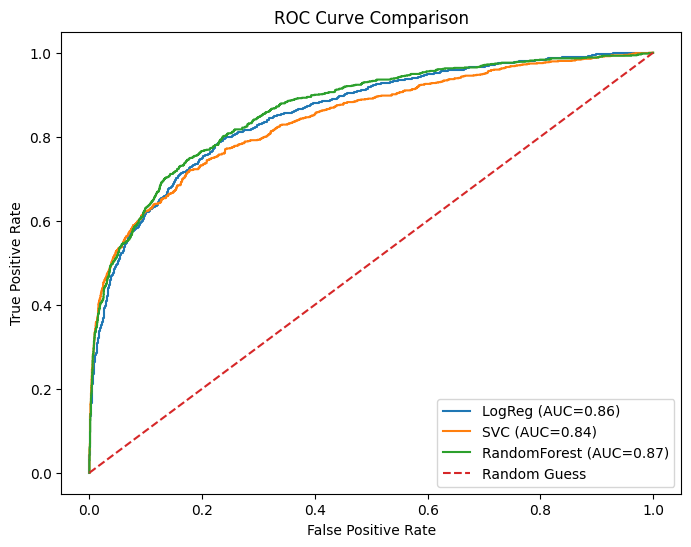

In [104]:

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={auc_lr:.2f})")
plt.plot(fpr_svc, tpr_svc, label=f"SVC (AUC={auc_svc:.2f})")
plt.plot(fpr_rfc, tpr_rfc, label=f"RandomForest (AUC={auc_rfc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()